# Stock Market Analysis

## 1. Import Libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (11, 6)

## 2. Load the Dataset

In [7]:
df = pd.read_csv("stock_market_data.csv")

print("Dataset Loaded Successfully!")
df.head()


Dataset Loaded Successfully!


,Share,Category,Sector,RM,Up,Last Traded Price,Percentage Change,High Price,Low Price,% High Movt
0,20MICRONS,Exit,CHEMICALS,NaN,NaN,43.00,NaN,NaN,NaN,NaN
1,3IINFOTECH,BWLV,IT,NaN,NaN,5.35,NaN,NaN,NaN,NaN
2,3MINDIA,Exit,DIVERSIFIED,0,0,12219.65,1.23,12399.95,12115.0,0.014540381
3,63MOONS,RS,IT,NaN,NaN,75.60,0.26,76.70,75.6,0.014341591
4,8KMILES,HWV,IT,0,0,623.90,0.17,640.00,624.0,0.02515625


In [8]:
print("Rows and Columns:", df.shape)

Rows and Columns: (1568, 10)


In [9]:
print(df.columns)

Index(['Share', 'Category', 'Sector', 'RM', 'Up', 'Last Traded Price',
       'Percentage Change', 'High Price', 'Low Price', '% High Movt'],
      dtype='str')


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1568 entries, 0 to 1567
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Share              1562 non-null   str    
 1   Category           1544 non-null   str    
 2   Sector             1560 non-null   str    
 3   RM                 578 non-null    str    
 4   Up                 583 non-null    str    
 5   Last Traded Price  1548 non-null   float64
 6   Percentage Change  969 non-null    float64
 7   High Price         969 non-null    float64
 8   Low Price          969 non-null    float64
 9   % High Movt        958 non-null    str    
dtypes: float64(4), str(6)
memory usage: 122.6 KB


In [11]:
df.describe()

,Last Traded Price,Percentage Change,High Price,Low Price
count,1548.000000,969.000000,969.000000,969.000000
mean,510.041932,-0.002828,703.291434,683.902683
std,2166.820789,2.070865,2753.304095,2673.383462
min,0.150000,-10.000000,0.000000,0.000000
25%,43.850000,-1.080000,93.600000,91.100000
50%,140.850000,-0.200000,241.000000,231.100000
75%,420.950000,0.670000,569.000000,559.350000
max,65936.700000,15.350000,67371.800000,65902.100000


## 3. Data Cleaning

In [12]:
df.isnull().sum()

Share                  6
Category              24
Sector                 8
RM                   990
Up                   985
Last Traded Price     20
Percentage Change    599
High Price           599
Low Price            599
% High Movt          610
dtype: int64

In [13]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 5


In [14]:
# "RM" and "Up" are mostly missing/corrupted (Excel #REF! errors, stray text) — not usable, drop them
df = df.drop(columns=["RM", "Up"], errors="ignore")

# Replace any remaining Excel error strings with NaN
df = df.replace(["#N/A", "#REF!", "#VALUE!"], np.nan)

# % High Movt was read as text in places — force numeric
df["% High Movt"] = pd.to_numeric(df["% High Movt"], errors="coerce")

# Rows with no price data at all aren't useful for this analysis
df = df.dropna(subset=["Last Traded Price"])

print("Shape after cleaning:", df.shape)
df.isnull().sum()

Shape after cleaning: (1548, 8)


Share                  0
Category              18
Sector                 8
Last Traded Price      0
Percentage Change    579
High Price           579
Low Price            579
% High Movt          603
dtype: int64

## 4. Sector-Wise Overview

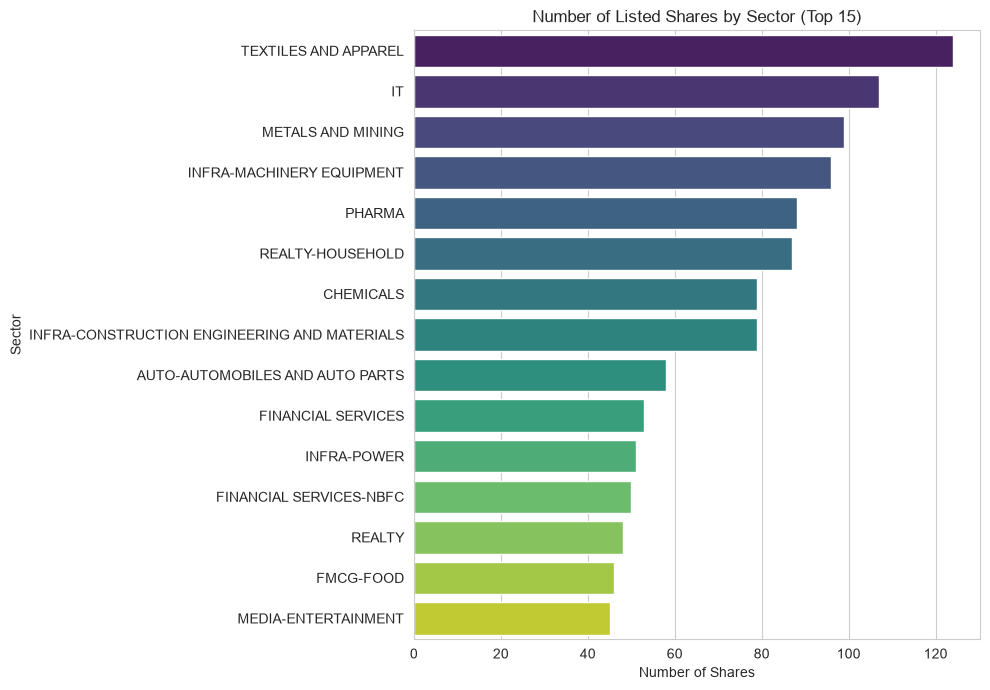

In [15]:
sector_counts = df["Sector"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(x=sector_counts.values, y=sector_counts.index, hue=sector_counts.index,
            palette="viridis", legend=False, ax=ax)
ax.set_title("Number of Listed Shares by Sector (Top 15)")
ax.set_xlabel("Number of Shares")
ax.set_ylabel("Sector")
plt.tight_layout()
plt.show()

In [16]:
sector_avg_change = df.groupby("Sector")["Percentage Change"].mean().dropna().sort_values(ascending=False)
sector_avg_change.head(10)

Sector
FMCG-BEVERAGES                                  2.139375
CEMENTS                                         1.167500
AUTO-AUTOMOBILES AND AUTO PARTS                 1.010769
FMCG-FOOD                                       0.674583
PAPER                                           0.611250
INFRA-CONSTRUCTION ENGINEERING AND MATERIALS    0.571020
ENTERTAINMENT-HOTELS AND LEISURE                0.420769
FINANCIAL SERVICES                              0.395000
PHARMA                                          0.329091
MEDIA-ENTERTAINMENT                             0.315714
Name: Percentage Change, dtype: float64

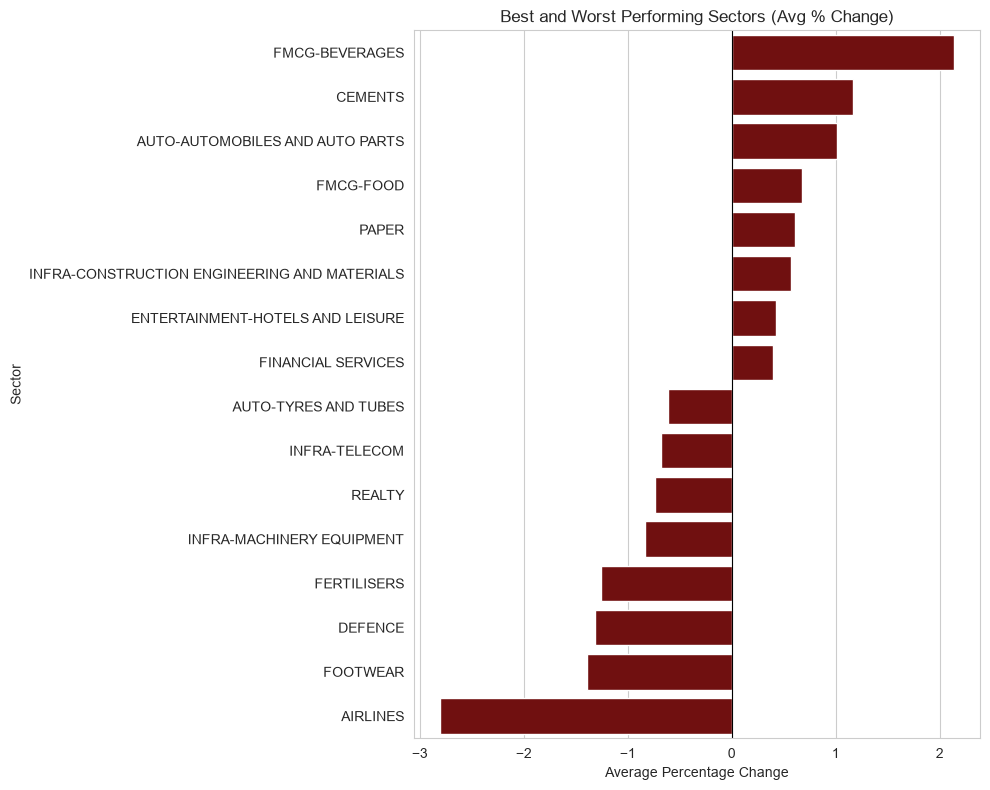

In [17]:
fig, ax = plt.subplots(figsize=(10, 8))
top_bottom = pd.concat([sector_avg_change.head(8), sector_avg_change.tail(8)])
colors = ["maroon" if v > 0 else "maroon" for v in top_bottom.values]
sns.barplot(x=top_bottom.values, y=top_bottom.index, hue=top_bottom.index,
            palette=colors, legend=False, ax=ax)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Best and Worst Performing Sectors (Avg % Change)")
ax.set_xlabel("Average Percentage Change")
ax.set_ylabel("Sector")
plt.tight_layout()
plt.show()


## 5. Trading Category / Signal Breakdown

Each share is tagged with a category (e.g. Buy, Exit, HWV, BWLV) — likely a technical screener signal.

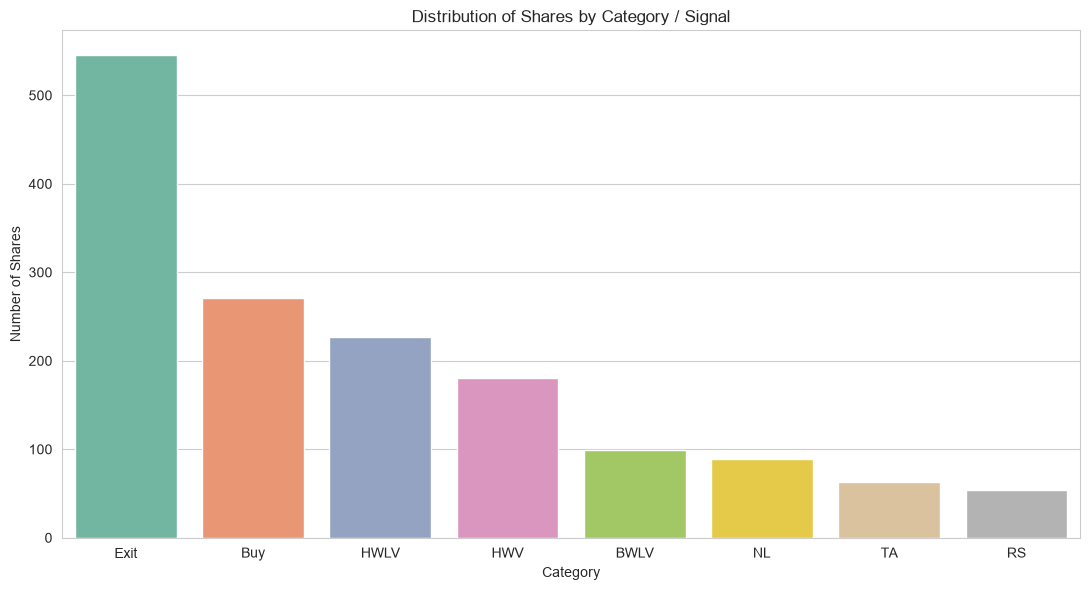

In [18]:
category_counts = df["Category"].value_counts()

fig, ax = plt.subplots()
sns.barplot(x=category_counts.index, y=category_counts.values, hue=category_counts.index,
            palette="Set2", legend=False, ax=ax)
ax.set_title("Distribution of Shares by Category / Signal")
ax.set_xlabel("Category")
ax.set_ylabel("Number of Shares")
plt.tight_layout()
plt.show()

In [19]:
df.groupby("Category")["Percentage Change"].mean().dropna().sort_values(ascending=False)

Category
RS      0.866667
HWV     0.219116
BWLV    0.217119
Exit    0.033982
HWLV    0.006406
NL     -0.116111
TA     -0.121667
Buy    -0.332111
Name: Percentage Change, dtype: float64

## 6. Top 10 Gainers and Losers

/var/folders/7m/2fnc3tz15hs8n5xyl2xjfz0r0000gn/T/ipykernel_4474/4130996735.py:4: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:maroon'` for the same effect.

  sns.barplot(data=top_gainers, x="Percentage Change", y="Share", hue="Share",


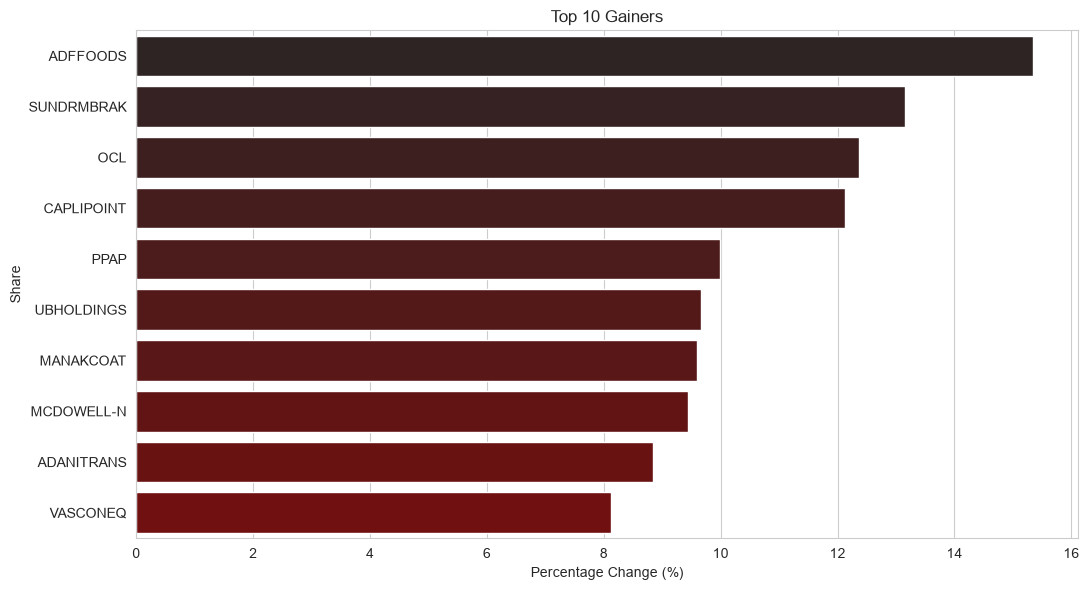

In [20]:
top_gainers = df.dropna(subset=["Percentage Change"]).sort_values("Percentage Change", ascending=False).head(10)

fig, ax = plt.subplots()
sns.barplot(data=top_gainers, x="Percentage Change", y="Share", hue="Share",
            color="maroon", legend=False, ax=ax)
ax.set_title("Top 10 Gainers")
ax.set_xlabel("Percentage Change (%)")
plt.tight_layout()
plt.show()


/var/folders/7m/2fnc3tz15hs8n5xyl2xjfz0r0000gn/T/ipykernel_4474/3858661557.py:4: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:maroon'` for the same effect.

  sns.barplot(data=top_losers, x="Percentage Change", y="Share", hue="Share",


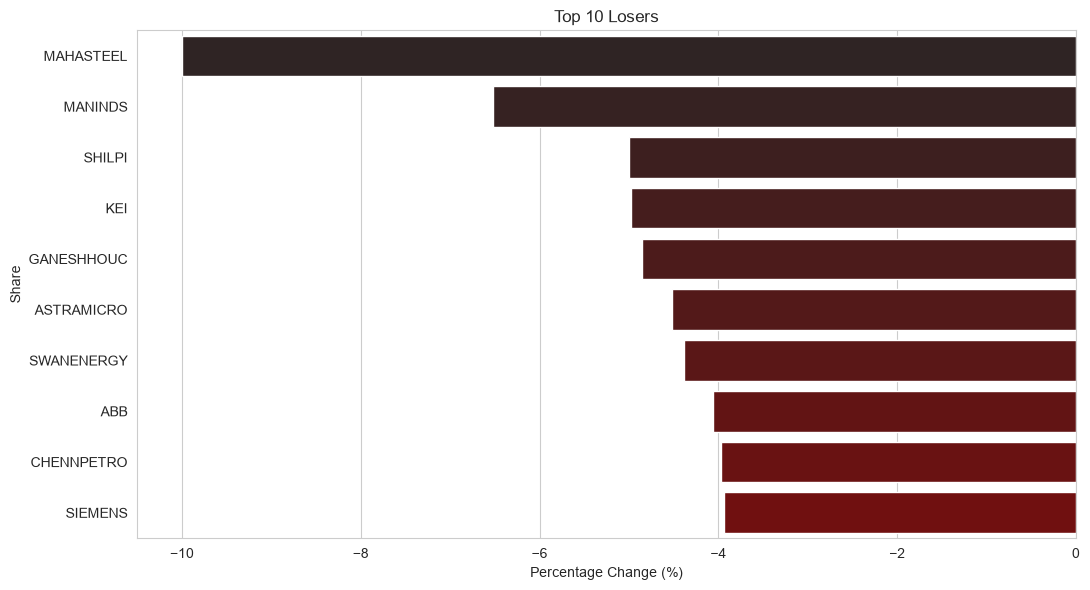

In [21]:
top_losers = df.dropna(subset=["Percentage Change"]).sort_values("Percentage Change", ascending=True).head(10)

fig, ax = plt.subplots()
sns.barplot(data=top_losers, x="Percentage Change", y="Share", hue="Share",
            color="maroon", legend=False, ax=ax)
ax.set_title("Top 10 Losers")
ax.set_xlabel("Percentage Change (%)")
plt.tight_layout()
plt.show()


## 7. Price Distribution

Share prices span a huge range (₹0.15 to ₹65,000+), so we look at this on a log scale.

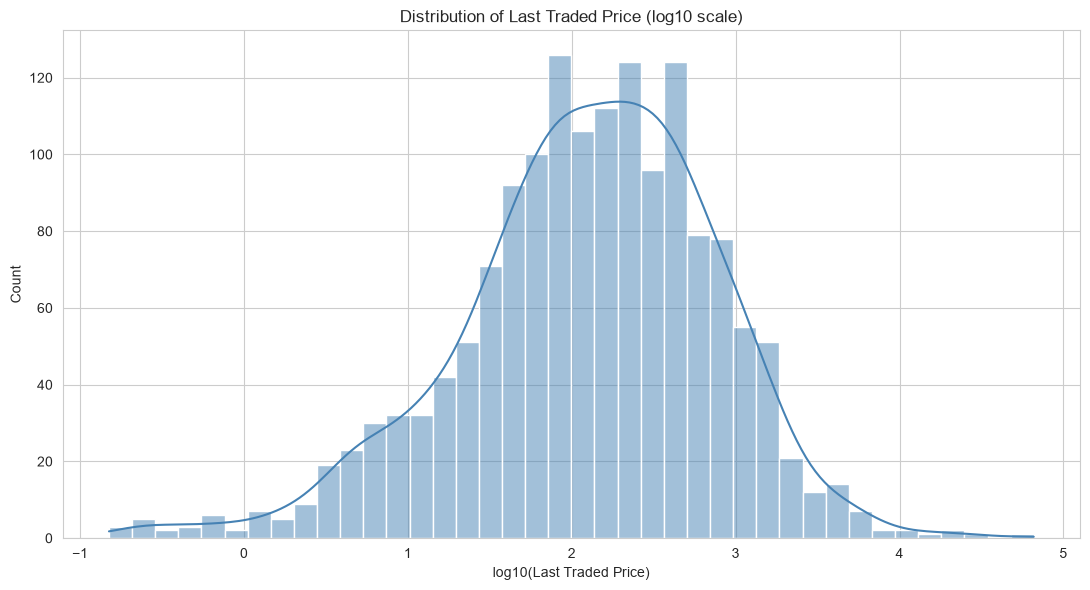

In [22]:
fig, ax = plt.subplots()
sns.histplot(np.log10(df["Last Traded Price"].dropna()), bins=40, kde=True, color="steelblue", ax=ax)
ax.set_title("Distribution of Last Traded Price (log10 scale)")
ax.set_xlabel("log10(Last Traded Price)")
plt.tight_layout()
plt.show()

## 8. Intraday Volatility (High - Low Range)

Using the day's high and low price as a simple proxy for volatility.

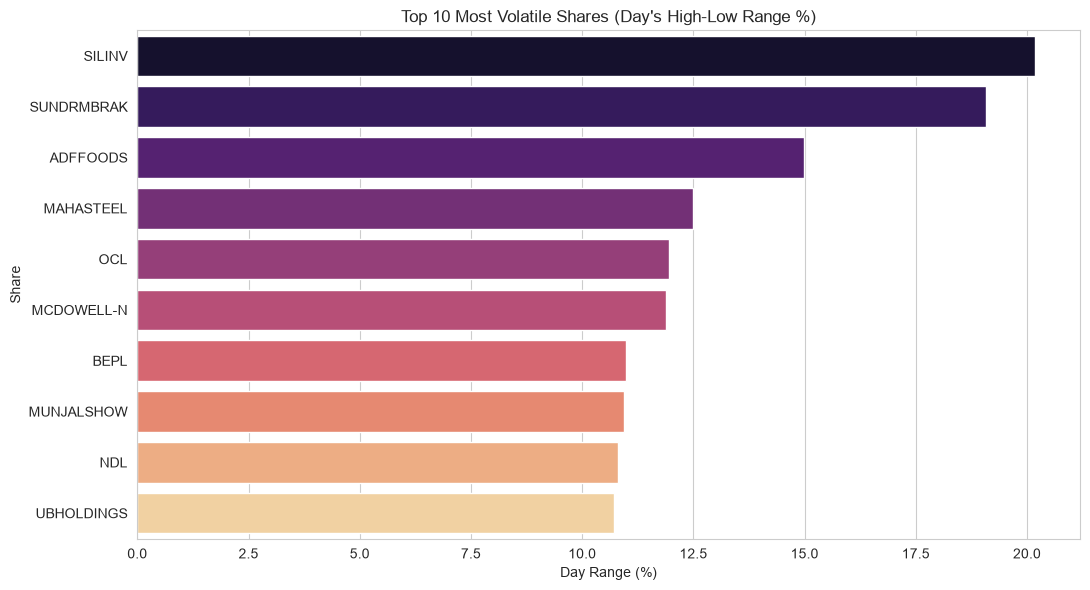

In [23]:
df["Day_Range_%"] = ((df["High Price"] - df["Low Price"]) / df["Low Price"]) * 100

most_volatile = df.dropna(subset=["Day_Range_%"]).sort_values("Day_Range_%", ascending=False).head(10)

fig, ax = plt.subplots()
sns.barplot(data=most_volatile, x="Day_Range_%", y="Share", hue="Share",
            palette="magma", legend=False, ax=ax)
ax.set_title("Top 10 Most Volatile Shares (Day's High-Low Range %)")
ax.set_xlabel("Day Range (%)")
plt.tight_layout()
plt.show()

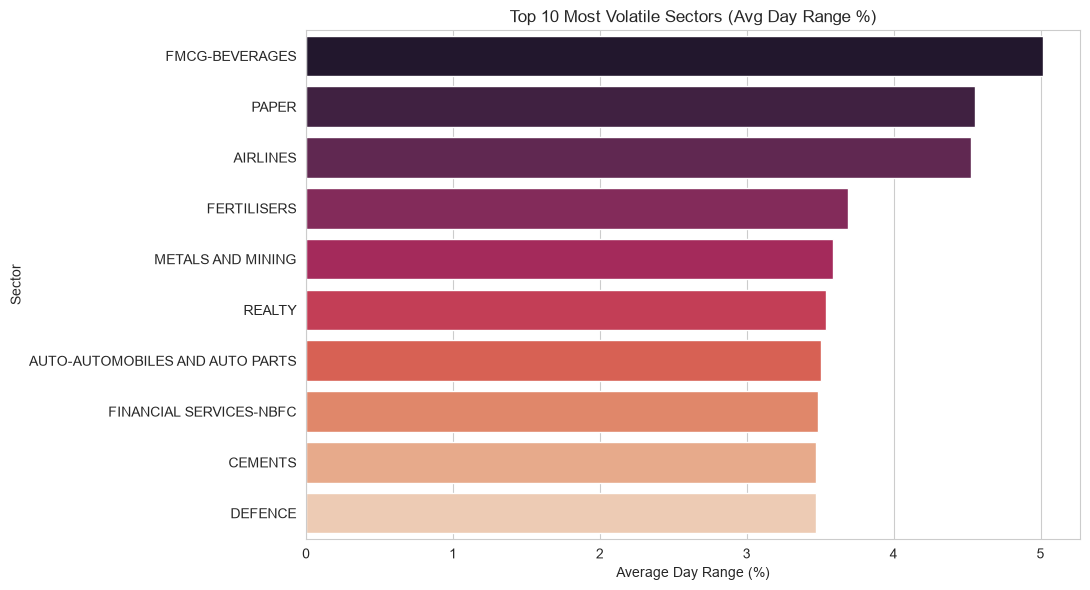

In [24]:
sector_volatility = df.groupby("Sector")["Day_Range_%"].mean().dropna().sort_values(ascending=False).head(10)

fig, ax = plt.subplots()
sns.barplot(x=sector_volatility.values, y=sector_volatility.index, hue=sector_volatility.index,
            palette="rocket", legend=False, ax=ax)
ax.set_title("Top 10 Most Volatile Sectors (Avg Day Range %)")
ax.set_xlabel("Average Day Range (%)")
ax.set_ylabel("Sector")
plt.tight_layout()
plt.show()

## 9. Correlation Between Numeric Indicators

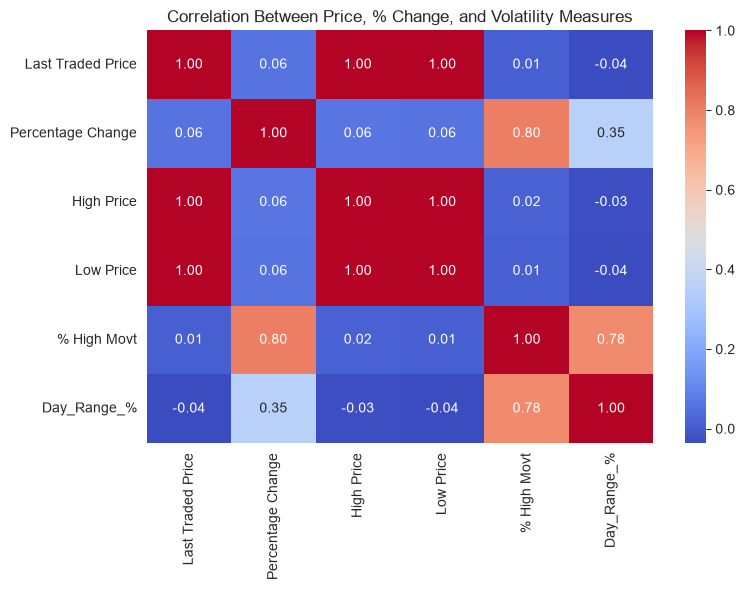

In [25]:
numeric_cols = ["Last Traded Price", "Percentage Change", "High Price", "Low Price", "% High Movt", "Day_Range_%"]
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", ax=ax)
ax.set_title("Correlation Between Price, % Change, and Volatility Measures")
plt.tight_layout()
plt.show()

## 10. Key Insights

Different sectors show different levels of market performance and volatility.
Some sectors have higher average percentage changes than others.
The analysis helps understand sector-wise stock-market trends.